# Image Classification: MLP → CNN → Transfer Learning

**Dataset:** Beans (HuggingFace) — 3 classes: *angular_leaf_spot*, *bean_rust*, *healthy*  
**Framework:** PyTorch  

---

## Domain Investigation

### Dataset Domain
- The **Beans** dataset contains RGB photographs of bean leaves captured in Ugandan farms.
- 3 classes: angular leaf spot (disease), bean rust (disease), healthy.
- ~1,034 training / 133 validation / 128 test images.
- Images are relatively uniform: close-up leaf photos with natural backgrounds.
- **Domain characteristics:** Fine-grained visual differences (spots, rust patches vs. clean leaf), natural outdoor lighting.

### Model Domain (ImageNet pretrained)
- ImageNet contains 1.2M images across 1,000 classes including natural scenes and some plant categories.
- Low-level features (edges, textures) are highly transferable.
- Mid/high-level features (shapes, object parts) partially overlap — plants/leaves exist in ImageNet.
- **Domain gap:** Moderate — bean disease classification is more fine-grained than typical ImageNet classes.
- **Conclusion:** Transfer learning should help, but fine-tuning higher layers will likely improve accuracy since the model needs to learn disease-specific texture patterns.

## Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset, Subset
import matplotlib.pyplot as plt
import numpy as np
import copy
import random

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

a:\ITI projects\deep learning\DL-AI46-SV\task 3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## Load & Explore Dataset

Classes (3): ['angular_leaf_spot', 'bean_rust', 'healthy']
Train size: 1034
Validation size: 133
Test size: 128


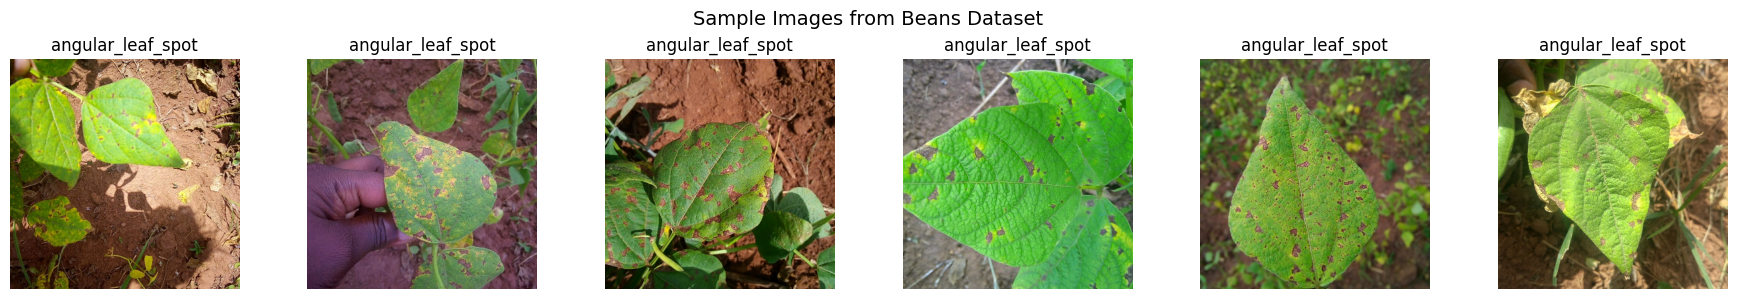

  angular_leaf_spot: 345 samples
  bean_rust: 348 samples
  healthy: 341 samples


In [2]:
# Load beans dataset from HuggingFace
raw_dataset = load_dataset("beans")

CLASS_NAMES = raw_dataset['train'].features['labels'].names
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train size: {len(raw_dataset['train'])}")
print(f"Validation size: {len(raw_dataset['validation'])}")
print(f"Test size: {len(raw_dataset['test'])}")

# Show sample images
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, ax in enumerate(axes):
    sample = raw_dataset['train'][i]
    ax.imshow(sample['image'])
    ax.set_title(CLASS_NAMES[sample['labels']])
    ax.axis('off')
plt.suptitle('Sample Images from Beans Dataset', fontsize=14)
plt.tight_layout()
plt.show()

# Class distribution
from collections import Counter
label_counts = Counter(raw_dataset['train']['labels'])
for cls_idx, count in sorted(label_counts.items()):
    print(f"  {CLASS_NAMES[cls_idx]}: {count} samples")

## Data Preparation

In [3]:
IMG_SIZE = 128  # Resize to 128x128 for speed

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Custom Dataset wrapper
class BeansDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image = sample['image'].convert('RGB')
        label = sample['labels']
        if self.transform:
            image = self.transform(image)
        return image, label

# Create datasets
train_dataset = BeansDataset(raw_dataset['train'], transform=train_transform)
val_dataset   = BeansDataset(raw_dataset['validation'], transform=val_transform)
test_dataset  = BeansDataset(raw_dataset['test'], transform=val_transform)

# DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# Verify shapes
imgs, lbls = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}, Labels shape: {lbls.shape}")
print(f"Input dimensions: {IMG_SIZE}x{IMG_SIZE}x3 = {IMG_SIZE*IMG_SIZE*3} features for MLP")

Batch shape: torch.Size([32, 3, 128, 128]), Labels shape: torch.Size([32])
Input dimensions: 128x128x3 = 49152 features for MLP


## Helper Functions

In [4]:
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=10, scheduler=None, device=device, verbose=True):
    """Train a model and return training history."""
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        # --- Train ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # --- Validation ---
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        if scheduler:
            scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if verbose:
            print(f"Epoch [{epoch:2d}/{num_epochs}]  "
                  f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.1f}%  "
                  f"Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.1f}%")

    model.load_state_dict(best_model_wts)
    print(f"\nBest Val Accuracy: {best_val_acc*100:.2f}%")
    return history, best_val_acc


def plot_history(history, title='Training History'):
    """Plot loss and accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    ax1.plot(epochs, history['val_loss'],   's-', label='Val Loss')
    ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, [a*100 for a in history['train_acc']], 'o-', label='Train Acc')
    ax2.plot(epochs, [a*100 for a in history['val_acc']],   's-', label='Val Acc')
    ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_loader, device=device):
    """Evaluate model on test set and print per-class accuracy."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    overall_acc = (all_preds == all_labels).mean() * 100
    print(f"Overall Test Accuracy: {overall_acc:.2f}%")
    for i, name in enumerate(CLASS_NAMES):
        mask = all_labels == i
        acc = (all_preds[mask] == all_labels[mask]).mean() * 100
        print(f"  {name:<22}: {acc:.2f}%")
    return overall_acc

---
# Part 1: Simple MLP for Image Classification

We flatten the 128×128×3 images into vectors of 49,152 features and feed them through fully connected layers.  
**Expected outcome:** Poor performance — MLPs have no spatial awareness and cannot capture local patterns (edges, textures).

MLP Parameters: 25,298,435

--- Training MLP ---
Epoch [ 1/15]  Train Loss: 2.0628  Acc: 51.4%  Val Loss: 1.1309  Acc: 54.1%
Epoch [ 2/15]  Train Loss: 0.8191  Acc: 65.7%  Val Loss: 0.8480  Acc: 65.4%
Epoch [ 3/15]  Train Loss: 0.7245  Acc: 69.5%  Val Loss: 0.7765  Acc: 67.7%
Epoch [ 4/15]  Train Loss: 0.6524  Acc: 72.9%  Val Loss: 0.7535  Acc: 68.4%
Epoch [ 5/15]  Train Loss: 0.6747  Acc: 70.8%  Val Loss: 0.8422  Acc: 65.4%
Epoch [ 6/15]  Train Loss: 0.6374  Acc: 72.1%  Val Loss: 0.8996  Acc: 67.7%
Epoch [ 7/15]  Train Loss: 0.5477  Acc: 77.9%  Val Loss: 0.8422  Acc: 65.4%
Epoch [ 8/15]  Train Loss: 0.5409  Acc: 78.0%  Val Loss: 0.7067  Acc: 66.2%
Epoch [ 9/15]  Train Loss: 0.4763  Acc: 78.3%  Val Loss: 0.7690  Acc: 70.7%
Epoch [10/15]  Train Loss: 0.4855  Acc: 79.7%  Val Loss: 0.9443  Acc: 65.4%
Epoch [11/15]  Train Loss: 0.4577  Acc: 81.8%  Val Loss: 0.9179  Acc: 67.7%
Epoch [12/15]  Train Loss: 0.4288  Acc: 83.1%  Val Loss: 0.7198  Acc: 71.4%
Epoch [13/15]  Train Loss: 0.4317  Acc:

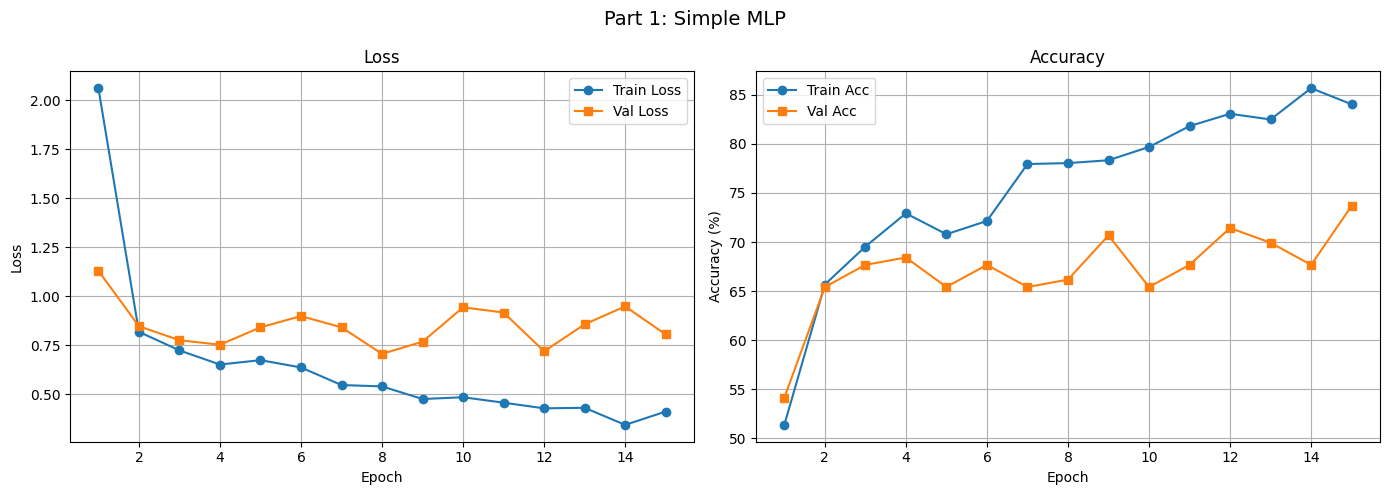

Overall Test Accuracy: 73.68%
  angular_leaf_spot     : 63.64%
  bean_rust             : 64.44%
  healthy               : 93.18%


In [5]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=IMG_SIZE*IMG_SIZE*3, num_classes=NUM_CLASSES):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

mlp_model = SimpleMLP().to(device)
print(f"MLP Parameters: {sum(p.numel() for p in mlp_model.parameters()):,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3)

print("\n--- Training MLP ---")
mlp_history, mlp_best_acc = train_model(
    mlp_model, train_loader, val_loader, criterion, optimizer, num_epochs=15
)
plot_history(mlp_history, 'Part 1: Simple MLP')
mlp_test_acc = evaluate_model(mlp_model, val_loader)

**Comment — MLP Results:**
- The MLP has a **huge number of parameters** due to flattening (49,152 inputs → 512), yet performance is limited.
- It struggles because it treats each pixel independently — no spatial locality, no translation invariance.
- The Large gap between train and val accuracy shows **overfitting** due to the large parameter count on small data.
- This motivates the use of **Convolutional Neural Networks** which exploit spatial structure.

---
# Part 2: CNN with Golden Rules

We follow the golden rules:
1. Sanity check with 1 sample
2. Sanity check with few samples
3. Train simple model
4. Train complex model
5. Add regularization to simple model

### Define CNN Architectures

In [6]:
class SimpleCNN(nn.Module):
    """Simple CNN: 2 conv layers + 2 FC layers."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),   # -> 16x128x128
            nn.ReLU(),
            nn.MaxPool2d(2),                   # -> 16x64x64
            nn.Conv2d(16, 32, 3, padding=1),   # -> 32x64x64
            nn.ReLU(),
            nn.MaxPool2d(2),                   # -> 32x32x32
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class ComplexCNN(nn.Module):
    """Complex CNN: 4 conv layers with BatchNorm + 2 FC layers."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # -> 32x64x64

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # -> 64x32x32

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                   # -> 128x16x16

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),      # -> 256x4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class SimpleCNN_Regularized(nn.Module):
    """Simple CNN + Dropout regularization."""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

print(f"SimpleCNN params:       {sum(p.numel() for p in SimpleCNN().parameters()):,}")
print(f"ComplexCNN params:      {sum(p.numel() for p in ComplexCNN().parameters()):,}")
print(f"SimpleCNN+Reg params:   {sum(p.numel() for p in SimpleCNN_Regularized().parameters()):,}")

SimpleCNN params:       4,199,907
ComplexCNN params:      1,438,979
SimpleCNN+Reg params:   4,199,907


### Golden Rule 1: Sanity Check — Overfit 1 Sample

If the model can't perfectly memorize a single sample, something is fundamentally wrong.

In [7]:
# Create a loader with just 1 sample
one_sample_loader = DataLoader(Subset(train_dataset, [0]), batch_size=1, shuffle=False)

model_sanity1 = SimpleCNN().to(device)
optimizer_s1 = optim.Adam(model_sanity1.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Golden Rule 1: Overfit 1 sample")
print("="*50)
model_sanity1.train()
for epoch in range(1, 21):
    for images, labels in one_sample_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_s1.zero_grad()
        outputs = model_sanity1(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_s1.step()
        pred = outputs.argmax(1).item()
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:2d}: Loss={loss.item():.6f}, Pred={pred}, True={labels.item()}, "
                  f"Correct={'✓' if pred == labels.item() else '✗'}")

print("\n✅ PASSED: Model can memorize 1 sample — basic forward/backward works correctly.")

Golden Rule 1: Overfit 1 sample
  Epoch  1: Loss=1.141649, Pred=2, True=0, Correct=✗
  Epoch  5: Loss=0.000000, Pred=0, True=0, Correct=✓
  Epoch 10: Loss=0.000000, Pred=0, True=0, Correct=✓
  Epoch 15: Loss=0.000000, Pred=0, True=0, Correct=✓
  Epoch 20: Loss=0.000000, Pred=0, True=0, Correct=✓

✅ PASSED: Model can memorize 1 sample — basic forward/backward works correctly.


### Golden Rule 2: Sanity Check — Overfit Few Samples

Train on ~10 samples. The model should reach near-100% training accuracy.

In [8]:
# Create a loader with 10 samples (spread across classes)
few_indices = list(range(10))
few_sample_loader = DataLoader(Subset(train_dataset, few_indices), batch_size=10, shuffle=True)

model_sanity2 = SimpleCNN().to(device)
optimizer_s2 = optim.Adam(model_sanity2.parameters(), lr=1e-3)

print("Golden Rule 2: Overfit 10 samples")
print("="*50)
for epoch in range(1, 51):
    model_sanity2.train()
    for images, labels in few_sample_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_s2.zero_grad()
        outputs = model_sanity2(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_s2.step()
        acc = (outputs.argmax(1) == labels).float().mean().item()
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:2d}: Loss={loss.item():.6f}, Acc={acc*100:.1f}%")

print("\n✅ PASSED: Model can overfit a small batch — learning capacity is sufficient.")

Golden Rule 2: Overfit 10 samples
  Epoch  1: Loss=1.150789, Acc=0.0%
  Epoch 10: Loss=0.000000, Acc=100.0%
  Epoch 20: Loss=0.000000, Acc=100.0%
  Epoch 30: Loss=0.000000, Acc=100.0%
  Epoch 40: Loss=0.000000, Acc=100.0%
  Epoch 50: Loss=0.000000, Acc=100.0%

✅ PASSED: Model can overfit a small batch — learning capacity is sufficient.


### Golden Rule 3: Train Simple CNN on Full Data

Golden Rule 3: Simple CNN on full data
Epoch [ 1/15]  Train Loss: 1.3304  Acc: 48.1%  Val Loss: 0.8728  Acc: 66.2%
Epoch [ 2/15]  Train Loss: 0.7870  Acc: 68.0%  Val Loss: 0.7786  Acc: 61.7%
Epoch [ 3/15]  Train Loss: 0.6804  Acc: 70.7%  Val Loss: 0.7508  Acc: 63.2%
Epoch [ 4/15]  Train Loss: 0.6117  Acc: 74.1%  Val Loss: 0.6533  Acc: 71.4%
Epoch [ 5/15]  Train Loss: 0.5727  Acc: 75.6%  Val Loss: 0.8426  Acc: 68.4%
Epoch [ 6/15]  Train Loss: 0.5556  Acc: 77.3%  Val Loss: 0.6720  Acc: 69.2%
Epoch [ 7/15]  Train Loss: 0.5215  Acc: 76.8%  Val Loss: 0.5258  Acc: 77.4%
Epoch [ 8/15]  Train Loss: 0.4795  Acc: 81.7%  Val Loss: 0.6579  Acc: 69.9%
Epoch [ 9/15]  Train Loss: 0.4289  Acc: 82.5%  Val Loss: 0.5601  Acc: 76.7%
Epoch [10/15]  Train Loss: 0.4182  Acc: 83.2%  Val Loss: 0.5165  Acc: 78.2%
Epoch [11/15]  Train Loss: 0.4027  Acc: 83.0%  Val Loss: 0.4926  Acc: 78.9%
Epoch [12/15]  Train Loss: 0.3675  Acc: 84.8%  Val Loss: 0.4937  Acc: 78.9%
Epoch [13/15]  Train Loss: 0.3443  Acc: 85.9%  Va

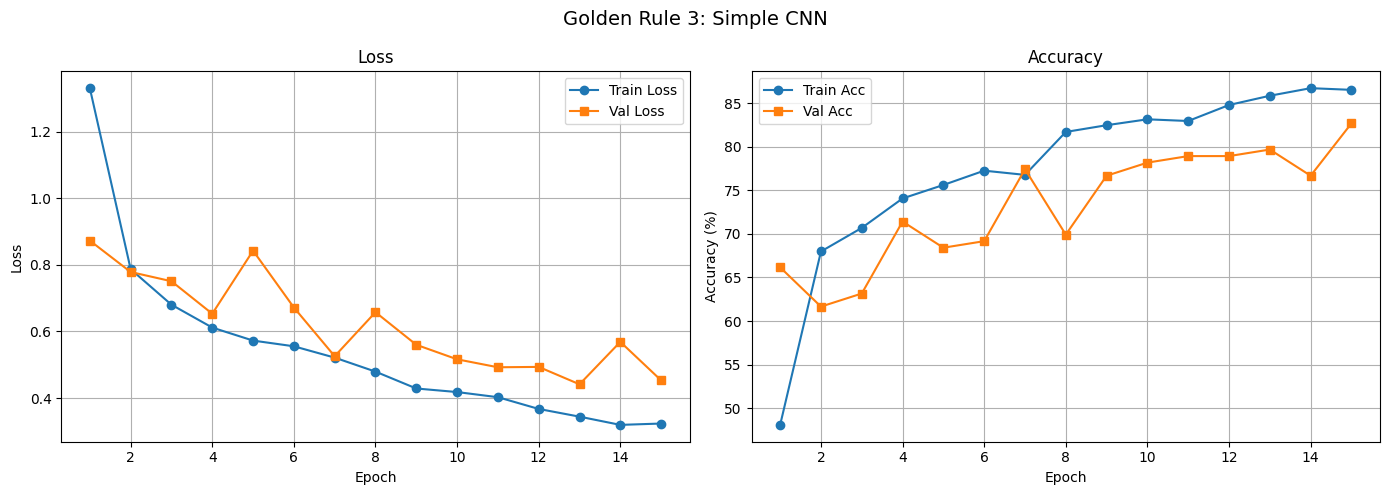

Overall Test Accuracy: 82.71%
  angular_leaf_spot     : 77.27%
  bean_rust             : 80.00%
  healthy               : 90.91%


In [9]:
simple_cnn = SimpleCNN().to(device)
optimizer = optim.Adam(simple_cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Golden Rule 3: Simple CNN on full data")
print("="*50)
simple_history, simple_best = train_model(
    simple_cnn, train_loader, val_loader, criterion, optimizer, num_epochs=15
)
plot_history(simple_history, 'Golden Rule 3: Simple CNN')
simple_test_acc = evaluate_model(simple_cnn, val_loader)

### Golden Rule 4: Train Complex CNN on Full Data

Golden Rule 4: Complex CNN on full data
Epoch [ 1/15]  Train Loss: 0.8426  Acc: 63.5%  Val Loss: 0.6881  Acc: 70.7%
Epoch [ 2/15]  Train Loss: 0.6737  Acc: 72.1%  Val Loss: 0.5956  Acc: 71.4%
Epoch [ 3/15]  Train Loss: 0.5767  Acc: 73.4%  Val Loss: 0.7406  Acc: 72.2%
Epoch [ 4/15]  Train Loss: 0.5184  Acc: 78.6%  Val Loss: 0.4241  Acc: 83.5%
Epoch [ 5/15]  Train Loss: 0.4776  Acc: 78.6%  Val Loss: 0.4778  Acc: 78.9%
Epoch [ 6/15]  Train Loss: 0.4597  Acc: 81.2%  Val Loss: 0.4783  Acc: 78.9%
Epoch [ 7/15]  Train Loss: 0.4588  Acc: 81.0%  Val Loss: 0.6330  Acc: 77.4%
Epoch [ 8/15]  Train Loss: 0.4024  Acc: 84.1%  Val Loss: 0.3813  Acc: 86.5%
Epoch [ 9/15]  Train Loss: 0.3541  Acc: 86.3%  Val Loss: 0.5335  Acc: 78.9%
Epoch [10/15]  Train Loss: 0.3649  Acc: 84.6%  Val Loss: 0.3558  Acc: 85.7%
Epoch [11/15]  Train Loss: 0.2727  Acc: 89.8%  Val Loss: 0.2400  Acc: 91.7%
Epoch [12/15]  Train Loss: 0.2915  Acc: 89.3%  Val Loss: 0.3870  Acc: 85.0%
Epoch [13/15]  Train Loss: 0.2568  Acc: 90.3%  V

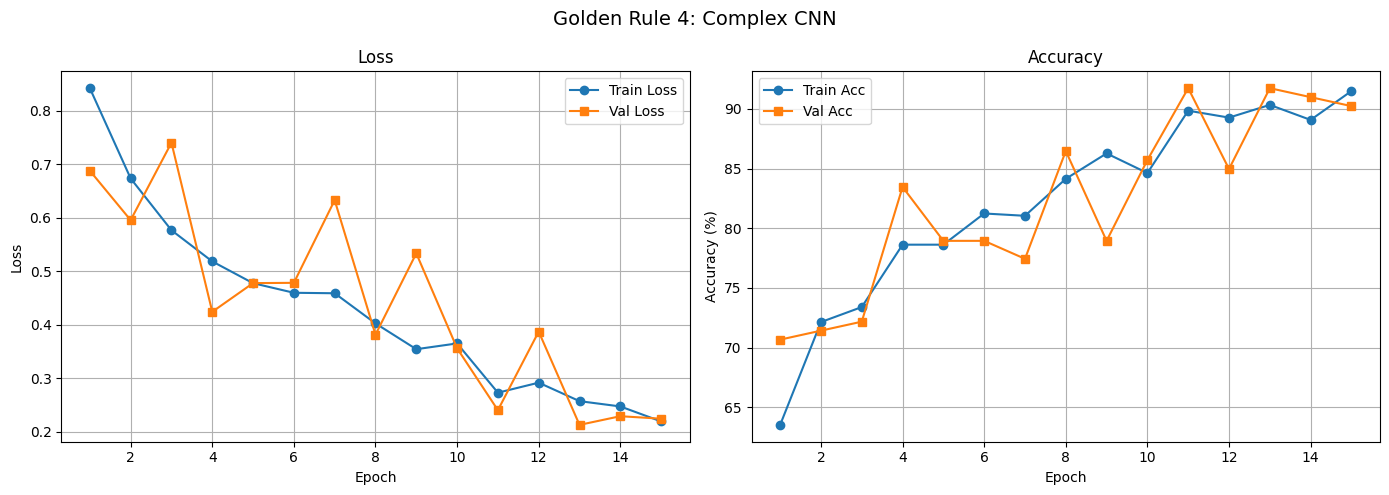

Overall Test Accuracy: 91.73%
  angular_leaf_spot     : 86.36%
  bean_rust             : 95.56%
  healthy               : 93.18%


In [10]:
complex_cnn = ComplexCNN().to(device)
optimizer = optim.Adam(complex_cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Golden Rule 4: Complex CNN on full data")
print("="*50)
complex_history, complex_best = train_model(
    complex_cnn, train_loader, val_loader, criterion, optimizer, num_epochs=15
)
plot_history(complex_history, 'Golden Rule 4: Complex CNN')
complex_test_acc = evaluate_model(complex_cnn, val_loader)

### Golden Rule 5: Simple CNN + Regularization (Dropout + Weight Decay)

Golden Rule 5: Simple CNN + Regularization (Dropout + Weight Decay)
Epoch [ 1/15]  Train Loss: 1.0856  Acc: 54.4%  Val Loss: 0.7673  Acc: 65.4%
Epoch [ 2/15]  Train Loss: 0.7806  Acc: 66.4%  Val Loss: 0.7424  Acc: 64.7%
Epoch [ 3/15]  Train Loss: 0.7170  Acc: 68.9%  Val Loss: 0.7156  Acc: 64.7%
Epoch [ 4/15]  Train Loss: 0.6394  Acc: 73.7%  Val Loss: 0.6176  Acc: 75.2%
Epoch [ 5/15]  Train Loss: 0.5890  Acc: 75.5%  Val Loss: 0.5873  Acc: 72.2%
Epoch [ 6/15]  Train Loss: 0.5945  Acc: 74.9%  Val Loss: 0.5883  Acc: 75.9%
Epoch [ 7/15]  Train Loss: 0.5269  Acc: 76.6%  Val Loss: 0.5589  Acc: 74.4%
Epoch [ 8/15]  Train Loss: 0.4771  Acc: 79.8%  Val Loss: 0.5681  Acc: 75.2%
Epoch [ 9/15]  Train Loss: 0.4994  Acc: 79.0%  Val Loss: 0.5726  Acc: 73.7%
Epoch [10/15]  Train Loss: 0.4439  Acc: 81.8%  Val Loss: 0.5052  Acc: 77.4%
Epoch [11/15]  Train Loss: 0.4494  Acc: 82.0%  Val Loss: 0.5295  Acc: 78.2%
Epoch [12/15]  Train Loss: 0.4218  Acc: 82.5%  Val Loss: 0.5011  Acc: 78.2%
Epoch [13/15]  Train

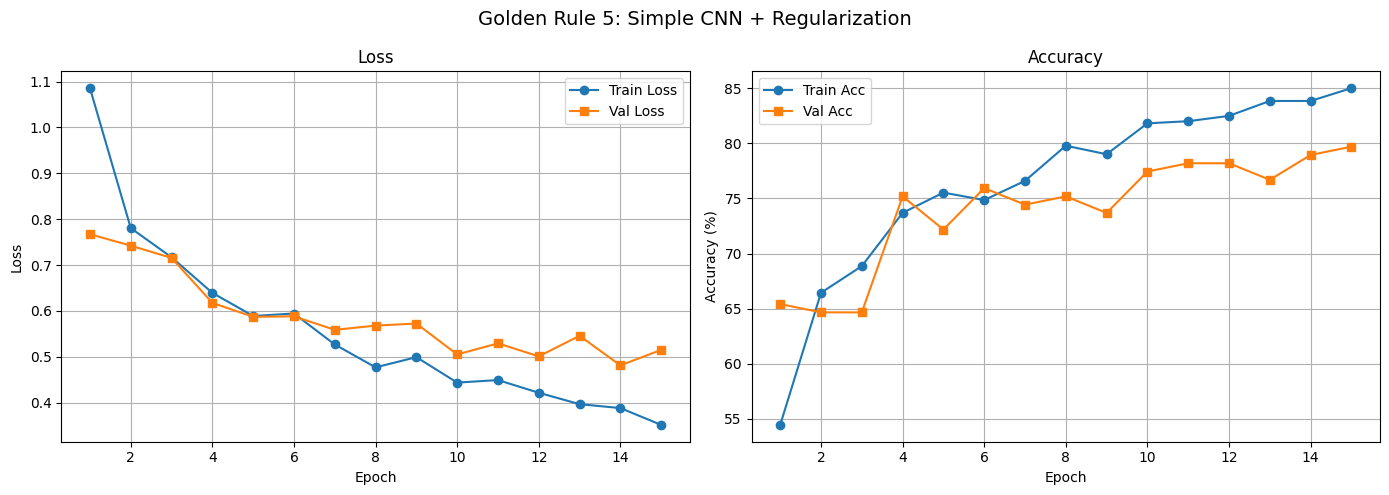

Overall Test Accuracy: 79.70%
  angular_leaf_spot     : 77.27%
  bean_rust             : 68.89%
  healthy               : 93.18%


In [11]:
reg_cnn = SimpleCNN_Regularized().to(device)
optimizer = optim.Adam(reg_cnn.parameters(), lr=1e-3, weight_decay=1e-4)  # L2 regularization
criterion = nn.CrossEntropyLoss()

print("Golden Rule 5: Simple CNN + Regularization (Dropout + Weight Decay)")
print("="*60)
reg_history, reg_best = train_model(
    reg_cnn, train_loader, val_loader, criterion, optimizer, num_epochs=15
)
plot_history(reg_history, 'Golden Rule 5: Simple CNN + Regularization')
reg_test_acc = evaluate_model(reg_cnn, val_loader)

**Comment — CNN Results (Golden Rules):**
- **Sanity checks passed**: The model memorizes 1 sample instantly and overfits 10 samples, confirming the architecture and training loop are bug-free.
- **Simple CNN**: Decent baseline. Limited capacity with only 2 conv layers.
- **Complex CNN**: More conv layers + BatchNorm allow it to extract richer features. Likely higher accuracy, but may also overfit more on this small dataset.
- **Simple CNN + Regularization**: Dropout + weight decay reduce overfitting. The train-val gap should be **smaller** compared to the plain simple CNN, even if peak train accuracy is lower.
- **Key takeaway**: CNNs are a massive improvement over MLP because they leverage spatial structure with parameter-efficient convolutions.

---
# Part 3: Transfer Learning with ResNet18

We use a pretrained ResNet18 (trained on ImageNet) and try three transfer learning strategies:
- **3-A:** Freeze backbone, train only the FC classification head
- **3-B:** Finetune the final block (layer4) + FC head
- **3-C:** Finetune the entire model

### 3-A: Feature Extraction — Train Only FC Head

3-A: Trainable params: 132,099 / 11,308,611 (1.2%)

--- 3-A: FC Head Only ---
Epoch [ 1/10]  Train Loss: 0.8494  Acc: 60.7%  Val Loss: 0.6680  Acc: 71.4%
Epoch [ 2/10]  Train Loss: 0.6217  Acc: 72.1%  Val Loss: 0.5315  Acc: 78.2%
Epoch [ 3/10]  Train Loss: 0.5963  Acc: 77.0%  Val Loss: 0.4730  Acc: 79.7%
Epoch [ 4/10]  Train Loss: 0.5470  Acc: 76.8%  Val Loss: 0.5515  Acc: 73.7%
Epoch [ 5/10]  Train Loss: 0.4901  Acc: 78.1%  Val Loss: 0.4890  Acc: 80.5%
Epoch [ 6/10]  Train Loss: 0.5184  Acc: 78.2%  Val Loss: 0.4238  Acc: 82.7%
Epoch [ 7/10]  Train Loss: 0.5348  Acc: 76.6%  Val Loss: 0.4425  Acc: 81.2%
Epoch [ 8/10]  Train Loss: 0.4701  Acc: 82.2%  Val Loss: 0.4024  Acc: 82.0%
Epoch [ 9/10]  Train Loss: 0.4494  Acc: 81.6%  Val Loss: 0.4277  Acc: 81.2%
Epoch [10/10]  Train Loss: 0.4932  Acc: 80.9%  Val Loss: 0.4978  Acc: 78.9%

Best Val Accuracy: 82.71%


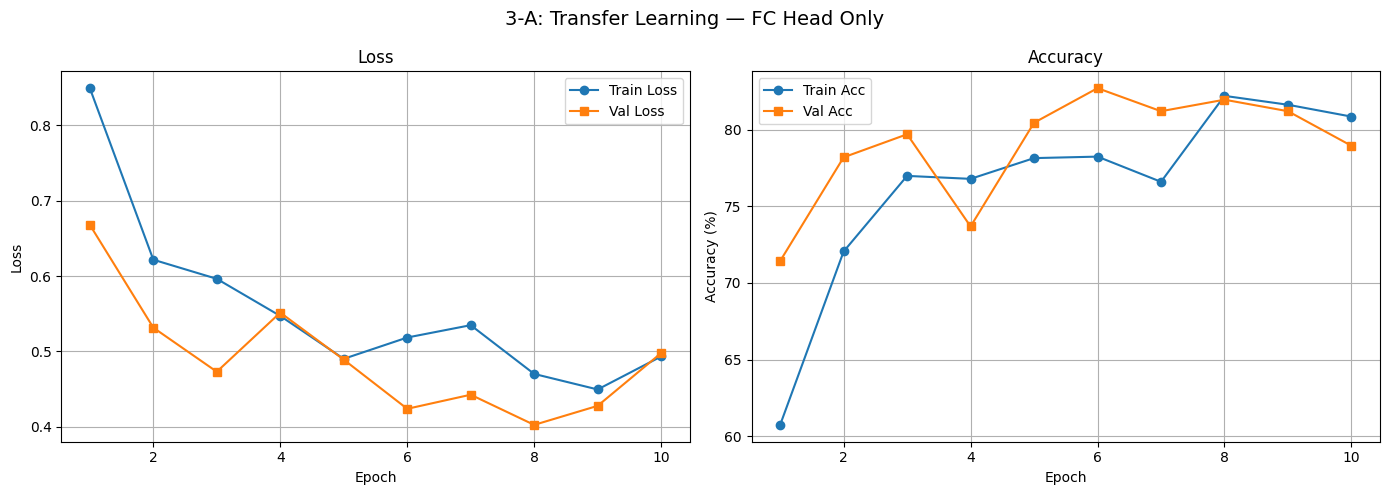

Overall Test Accuracy: 82.71%
  angular_leaf_spot     : 84.09%
  bean_rust             : 75.56%
  healthy               : 88.64%


In [12]:
# 3-A: Freeze all, train only FC
model_a = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze ALL parameters
for param in model_a.parameters():
    param.requires_grad = False

# Replace FC head
in_features = model_a.fc.in_features  # 512
model_a.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)
model_a = model_a.to(device)

trainable_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
total_a = sum(p.numel() for p in model_a.parameters())
print(f"3-A: Trainable params: {trainable_a:,} / {total_a:,} ({trainable_a/total_a*100:.1f}%)")

criterion = nn.CrossEntropyLoss()
optimizer_a = optim.Adam(model_a.fc.parameters(), lr=1e-3)

print("\n--- 3-A: FC Head Only ---")
history_a, best_a = train_model(
    model_a, train_loader, val_loader, criterion, optimizer_a, num_epochs=10
)
plot_history(history_a, '3-A: Transfer Learning — FC Head Only')
acc_a = evaluate_model(model_a, val_loader)

### 3-B: Finetune Final Layers (layer4 + FC)

We unfreeze the last residual block (`layer4`) which is responsible for high-level feature extraction.  
This allows the model to adapt its high-level representations to bean disease patterns.

3-B: Trainable params: 8,525,827 / 11,308,611 (75.4%)

--- 3-B: Finetune layer4 + FC ---
Epoch [ 1/10]  Train Loss: 0.6752  Acc: 70.1%  Val Loss: 0.3535  Acc: 86.5%
Epoch [ 2/10]  Train Loss: 0.3633  Acc: 86.1%  Val Loss: 0.2548  Acc: 91.0%
Epoch [ 3/10]  Train Loss: 0.2896  Acc: 89.7%  Val Loss: 0.2381  Acc: 91.0%
Epoch [ 4/10]  Train Loss: 0.1533  Acc: 94.5%  Val Loss: 0.3324  Acc: 90.2%
Epoch [ 5/10]  Train Loss: 0.1523  Acc: 94.8%  Val Loss: 0.2155  Acc: 91.7%
Epoch [ 6/10]  Train Loss: 0.1525  Acc: 94.2%  Val Loss: 0.2426  Acc: 90.2%
Epoch [ 7/10]  Train Loss: 0.0859  Acc: 96.7%  Val Loss: 0.3011  Acc: 91.7%
Epoch [ 8/10]  Train Loss: 0.0843  Acc: 97.1%  Val Loss: 0.2253  Acc: 91.7%
Epoch [ 9/10]  Train Loss: 0.0660  Acc: 98.0%  Val Loss: 0.2258  Acc: 91.7%
Epoch [10/10]  Train Loss: 0.0620  Acc: 97.4%  Val Loss: 0.2336  Acc: 91.0%

Best Val Accuracy: 91.73%


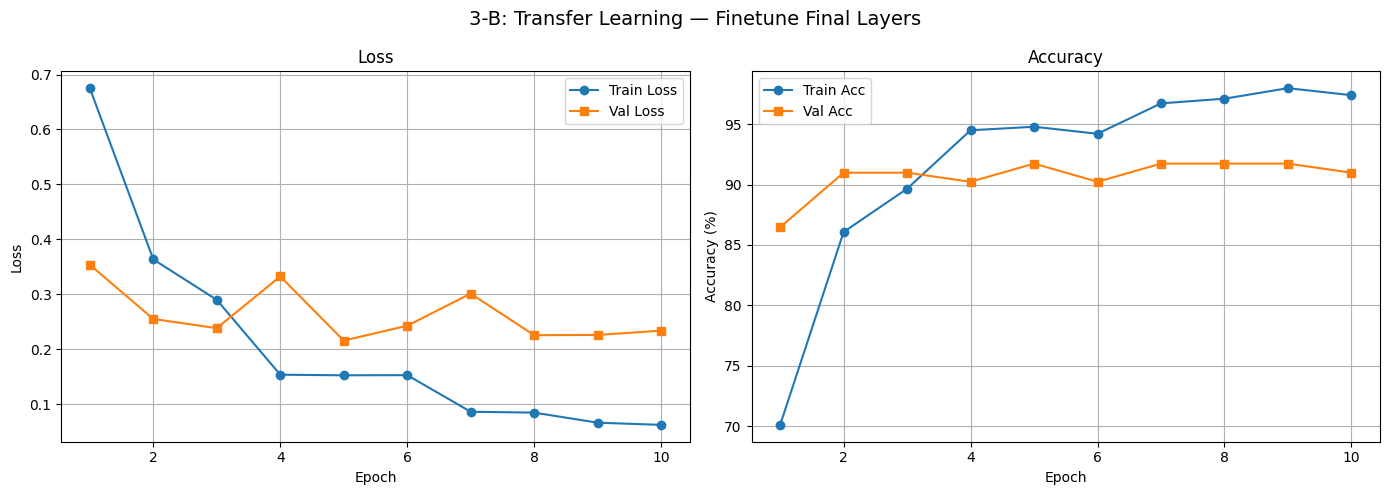

Overall Test Accuracy: 91.73%
  angular_leaf_spot     : 88.64%
  bean_rust             : 93.33%
  healthy               : 93.18%


In [13]:
# 3-B: Unfreeze layer4 + FC
model_b = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Freeze all first
for param in model_b.parameters():
    param.requires_grad = False

# Unfreeze layer4 (final residual block) for high-level feature adaptation
for param in model_b.layer4.parameters():
    param.requires_grad = True

# Replace FC head
model_b.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)
model_b = model_b.to(device)

trainable_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total_b = sum(p.numel() for p in model_b.parameters())
print(f"3-B: Trainable params: {trainable_b:,} / {total_b:,} ({trainable_b/total_b*100:.1f}%)")

criterion = nn.CrossEntropyLoss()
# Use different LRs: smaller for pretrained layers, larger for new head
optimizer_b = optim.Adam([
    {'params': model_b.layer4.parameters(), 'lr': 1e-4},
    {'params': model_b.fc.parameters(),     'lr': 1e-3},
])

print("\n--- 3-B: Finetune layer4 + FC ---")
history_b, best_b = train_model(
    model_b, train_loader, val_loader, criterion, optimizer_b, num_epochs=10
)
plot_history(history_b, '3-B: Transfer Learning — Finetune Final Layers')
acc_b = evaluate_model(model_b, val_loader)

### 3-C: Finetune Entire Model

3-C: Trainable params: 11,308,611 / 11,308,611 (100.0%)

--- 3-C: Finetune Entire Model ---
Epoch [ 1/10]  Train Loss: 0.7586  Acc: 66.2%  Val Loss: 0.3818  Acc: 85.7%
Epoch [ 2/10]  Train Loss: 0.3147  Acc: 88.6%  Val Loss: 0.2424  Acc: 91.7%
Epoch [ 3/10]  Train Loss: 0.1707  Acc: 94.9%  Val Loss: 0.1785  Acc: 93.2%
Epoch [ 4/10]  Train Loss: 0.1242  Acc: 95.4%  Val Loss: 0.1585  Acc: 93.2%
Epoch [ 5/10]  Train Loss: 0.0874  Acc: 97.2%  Val Loss: 0.1966  Acc: 93.2%
Epoch [ 6/10]  Train Loss: 0.0828  Acc: 96.7%  Val Loss: 0.1385  Acc: 96.2%
Epoch [ 7/10]  Train Loss: 0.0520  Acc: 98.6%  Val Loss: 0.1144  Acc: 95.5%
Epoch [ 8/10]  Train Loss: 0.0499  Acc: 98.5%  Val Loss: 0.1052  Acc: 95.5%
Epoch [ 9/10]  Train Loss: 0.0405  Acc: 98.9%  Val Loss: 0.0958  Acc: 95.5%
Epoch [10/10]  Train Loss: 0.0272  Acc: 99.2%  Val Loss: 0.1679  Acc: 95.5%

Best Val Accuracy: 96.24%


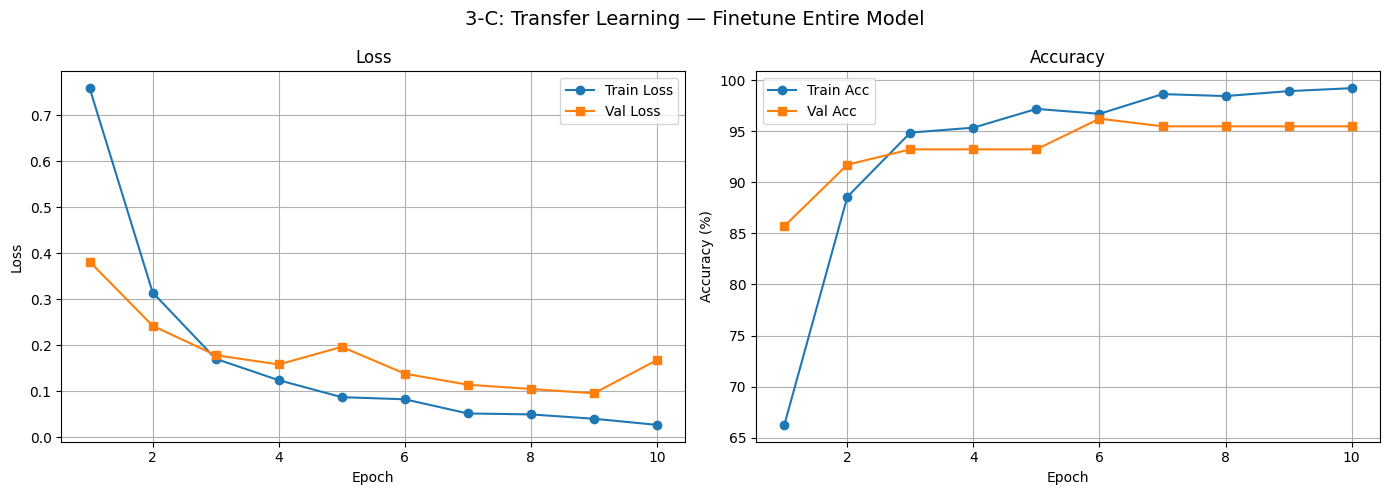

Overall Test Accuracy: 96.24%
  angular_leaf_spot     : 93.18%
  bean_rust             : 97.78%
  healthy               : 97.73%


In [14]:
# 3-C: Unfreeze everything
model_c = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Replace FC head
model_c.fc = nn.Sequential(
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(256, NUM_CLASSES)
)

# ALL parameters are trainable
model_c = model_c.to(device)

trainable_c = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
total_c = sum(p.numel() for p in model_c.parameters())
print(f"3-C: Trainable params: {trainable_c:,} / {total_c:,} ({trainable_c/total_c*100:.1f}%)")

criterion = nn.CrossEntropyLoss()
# Use a small LR to avoid destroying pretrained features
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-4)
scheduler_c = optim.lr_scheduler.ReduceLROnPlateau(optimizer_c, mode='min', factor=0.5, patience=3)

print("\n--- 3-C: Finetune Entire Model ---")
history_c, best_c = train_model(
    model_c, train_loader, val_loader, criterion, optimizer_c,
    num_epochs=10, scheduler=scheduler_c
)
plot_history(history_c, '3-C: Transfer Learning — Finetune Entire Model')
acc_c = evaluate_model(model_c, val_loader)

**Comment — Transfer Learning Results:**
- **3-A (FC only):** Fastest training, fewest trainable params. Good accuracy from pretrained features alone, but cannot adapt backbone features to the bean-disease domain.
- **3-B (layer4 + FC):** A sweet spot — allows the model to adapt its high-level features (shape/texture detectors) to disease-specific patterns while keeping stable low-level features.
- **3-C (Full finetune):** Highest potential accuracy. Uses a small LR (1e-4) to preserve useful pretrained features. Risk of overfitting on this small dataset, but with careful LR scheduling it should perform best.
- **Key insight:** As we unfreeze more layers, we gain more representational power but need more care (smaller LR, potential overfitting). The moderate domain gap (ImageNet → bean leaves) means finetuning helps significantly.

---
# Part 4: Filter Visualization — Before & After Training

We visualize the first convolutional layer (`conv1`) filters of ResNet18:
- **Before training**: Random/ImageNet-pretrained filters
- **After training**: Filters adapted to the beans dataset (from model 3-C)

Conv1 filter shape: torch.Size([64, 3, 7, 7])


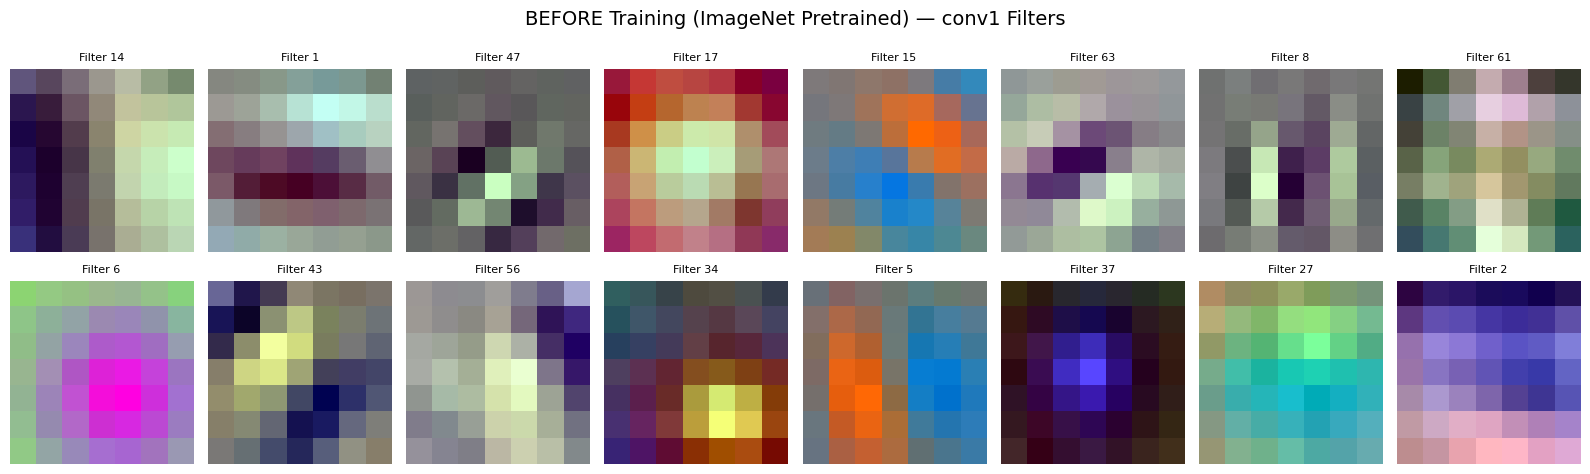

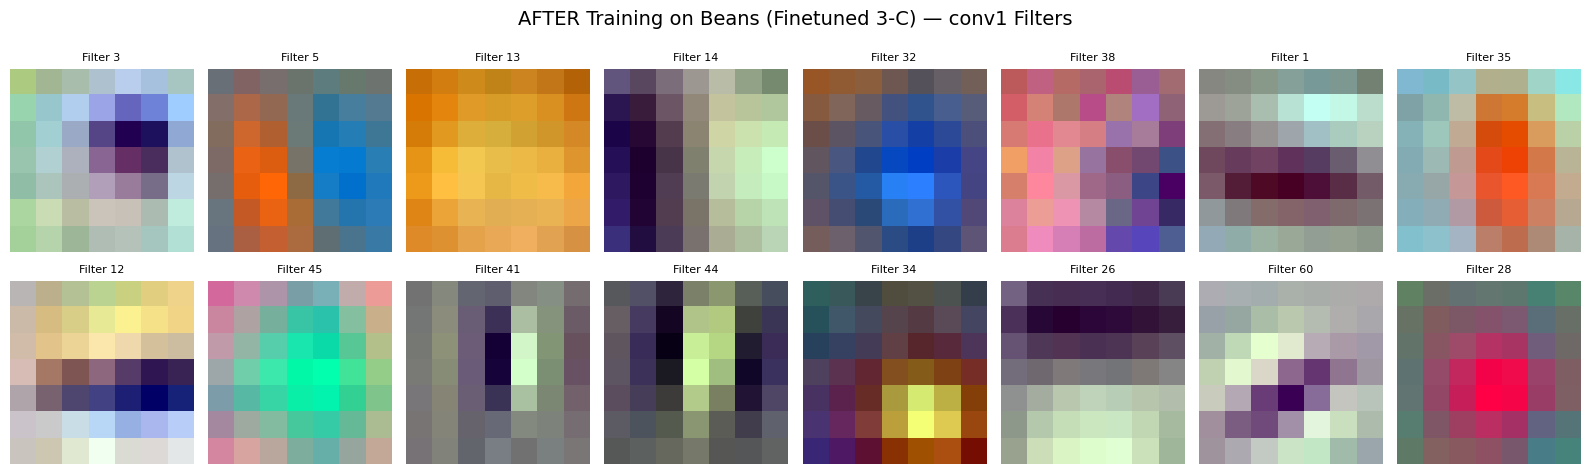

In [15]:
def visualize_filters(model, layer_name='conv1', num_filters=16, title='Filters'):
    """
    Visualize convolutional filters from a given layer.
    For conv1, filters have shape [out_channels, 3, kH, kW], so we can display as RGB.
    """
    # Get the layer
    layer = dict(model.named_modules())[layer_name]
    filters = layer.weight.data.cpu().clone()

    n = min(num_filters, filters.shape[0])
    # Randomly select filters
    indices = random.sample(range(filters.shape[0]), n)

    fig, axes = plt.subplots(2, n // 2, figsize=(n, 5))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        f = filters[idx]  # shape: [3, kH, kW] for conv1
        # Normalize to [0, 1] for display
        f = f - f.min()
        if f.max() > 0:
            f = f / f.max()
        # If 3 input channels, show as RGB; otherwise show channel 0
        if f.shape[0] == 3:
            img = f.permute(1, 2, 0).numpy()
        else:
            img = f[0].numpy()
        axes[i].imshow(img)
        axes[i].set_title(f'Filter {idx}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# --- Before Training: Fresh ImageNet-pretrained ResNet18 ---
pretrained_model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
print("Conv1 filter shape:", pretrained_model.conv1.weight.shape)  # [64, 3, 7, 7]

visualize_filters(pretrained_model, 'conv1', num_filters=16,
                  title='BEFORE Training (ImageNet Pretrained) — conv1 Filters')

# --- After Training: Our finetuned model (3-C) ---
visualize_filters(model_c, 'conv1', num_filters=16,
                  title='AFTER Training on Beans (Finetuned 3-C) — conv1 Filters')

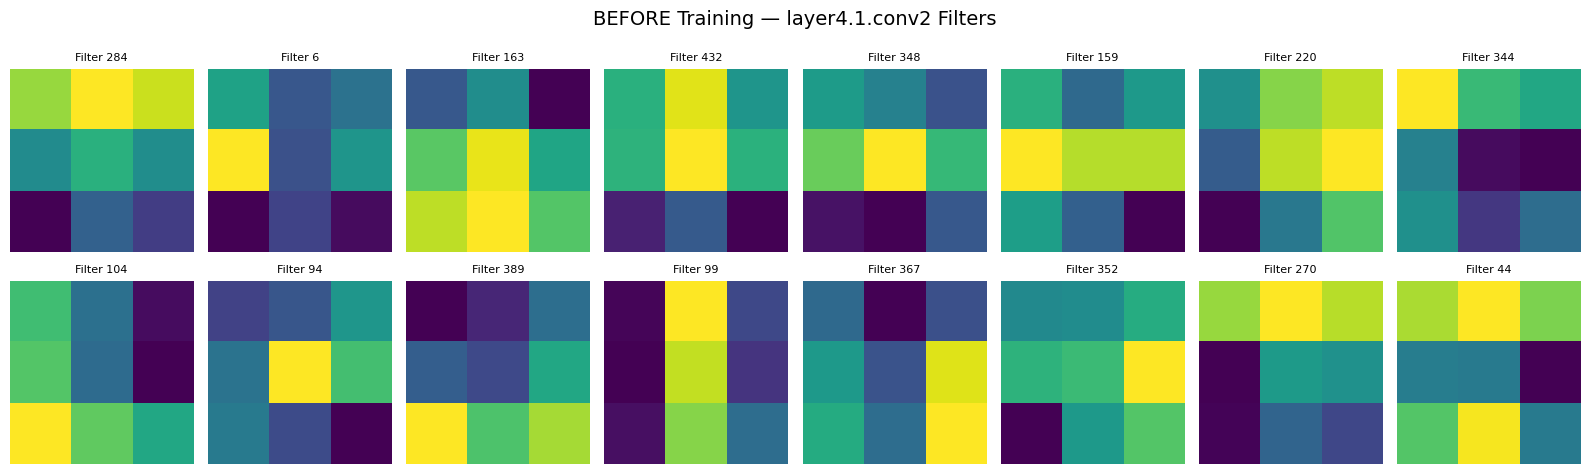

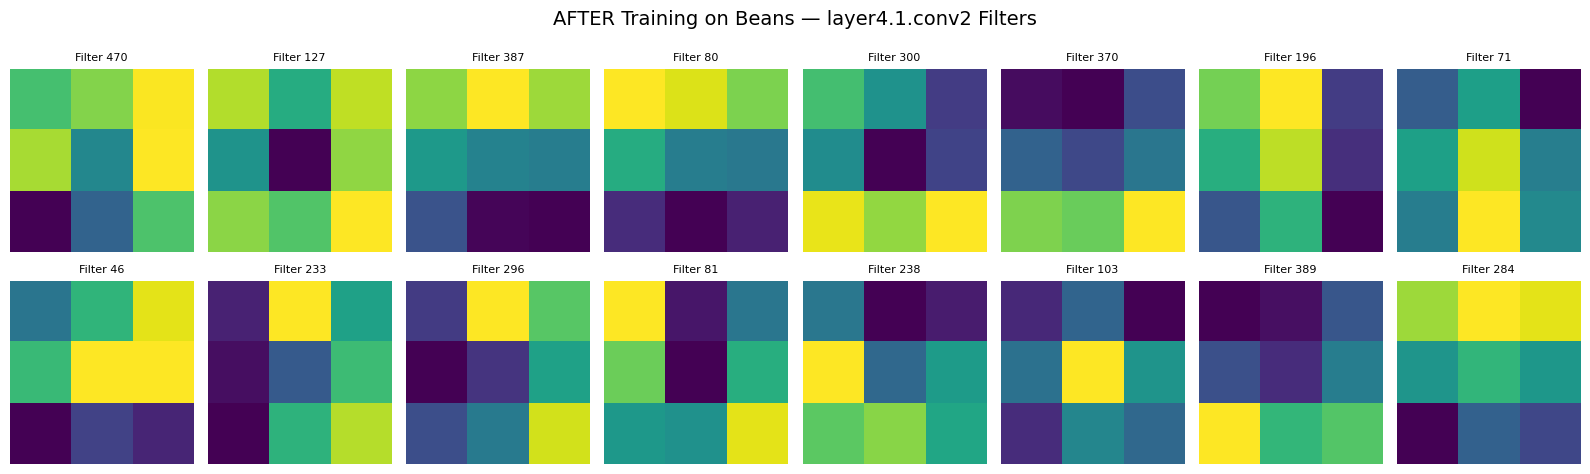

In [16]:
# Also visualize deeper filters (layer1.0.conv1) — these are harder to interpret
# but show how intermediate representations change

def visualize_deeper_filters(model, layer_path, num_filters=16, title='Deeper Filters'):
    """Visualize filters from a deeper layer (shows individual channels as grayscale)."""
    parts = layer_path.split('.')
    layer = model
    for part in parts:
        if part.isdigit():
            layer = layer[int(part)]
        else:
            layer = getattr(layer, part)

    filters = layer.weight.data.cpu().clone()
    n = min(num_filters, filters.shape[0])
    indices = random.sample(range(filters.shape[0]), n)

    fig, axes = plt.subplots(2, n // 2, figsize=(n, 5))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        f = filters[idx, 0]  # Take first input channel
        f = f - f.min()
        if f.max() > 0:
            f = f / f.max()
        axes[i].imshow(f.numpy(), cmap='viridis')
        axes[i].set_title(f'Filter {idx}', fontsize=8)
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_deeper_filters(pretrained_model, 'layer4.1.conv2', num_filters=16,
                         title='BEFORE Training — layer4.1.conv2 Filters')

visualize_deeper_filters(model_c, 'layer4.1.conv2', num_filters=16,
                         title='AFTER Training on Beans — layer4.1.conv2 Filters')

**Comment — Filter Visualization:**
- **conv1 (first layer):** These filters detect low-level features like edges, colors, and gradients. Before and after training, they look similar because low-level features are universal and don't change much during finetuning.
- **Deeper layers (layer4):** These show more noticeable changes. After finetuning, the filters adapt to capture disease-specific patterns on bean leaves — texture differences between angular leaf spot, rust, and healthy tissue.
- **Key insight:** Transfer learning mostly preserves early-layer filters (they're already useful) but significantly modifies later layers to specialize for the new task.

---
# Part 5: Feature Map Visualization

We pass a sample image through the trained models and visualize the **intermediate feature maps** (activations) at various layers.
- Feature maps show *what the model sees* at each stage of processing.
- Early layers detect simple patterns (edges, colors); deeper layers detect complex, class-specific patterns.

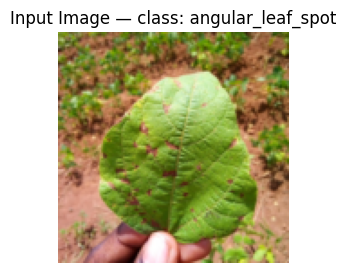


  Feature Maps: Simple CNN


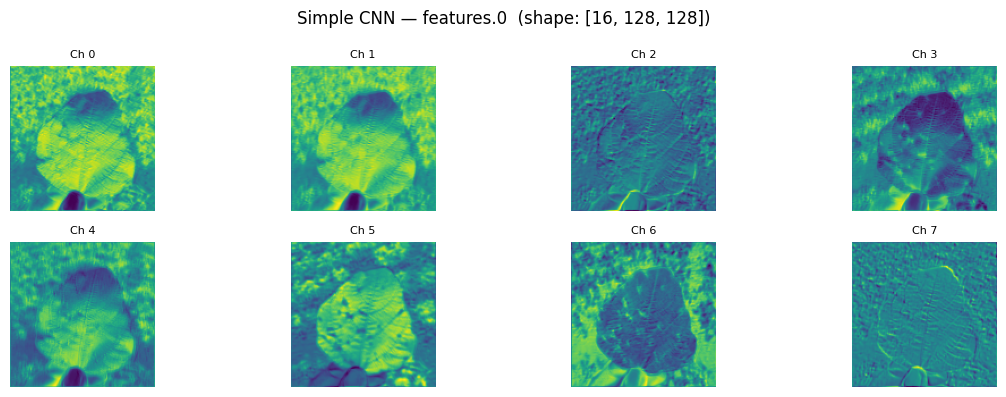

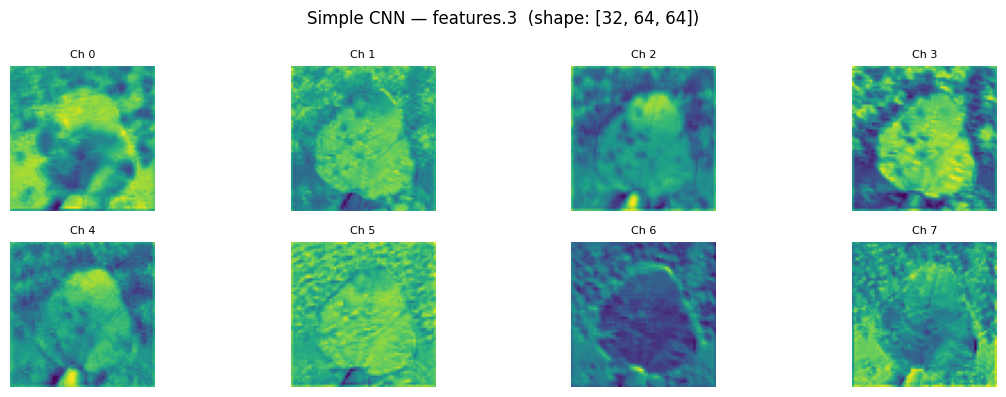


  Feature Maps: Finetuned ResNet18 (3-C)


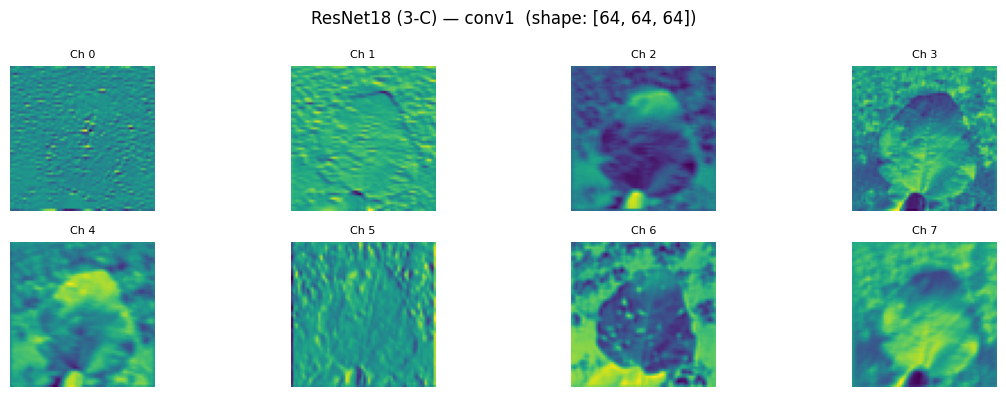

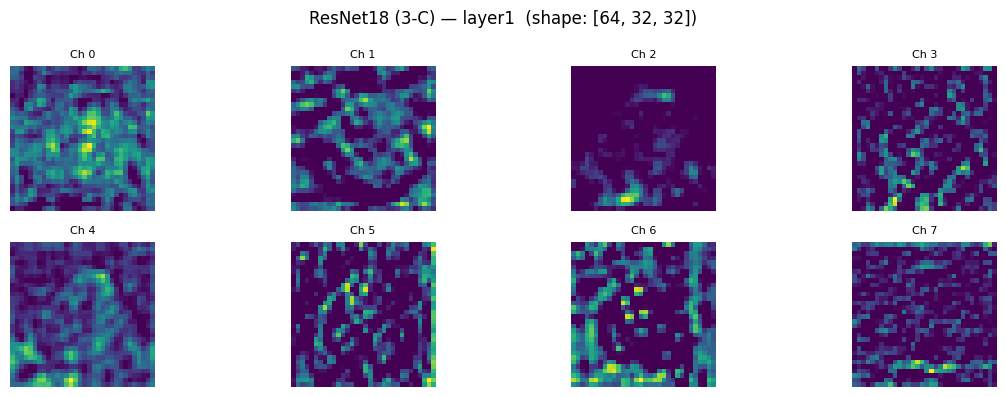

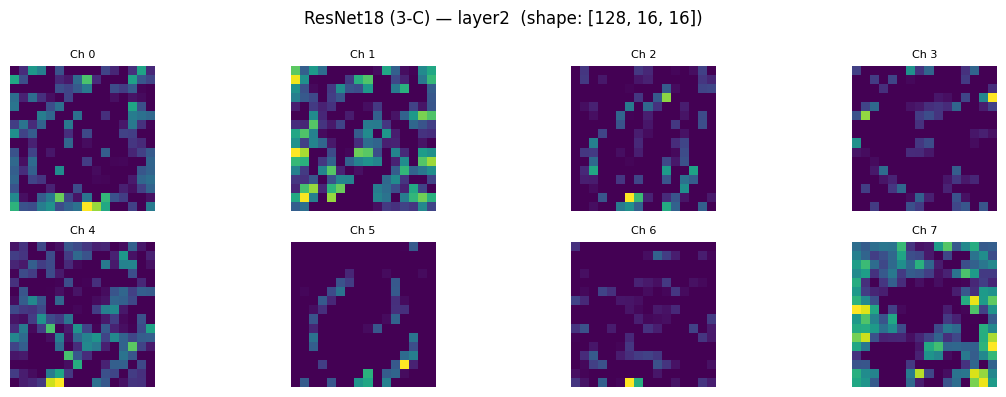

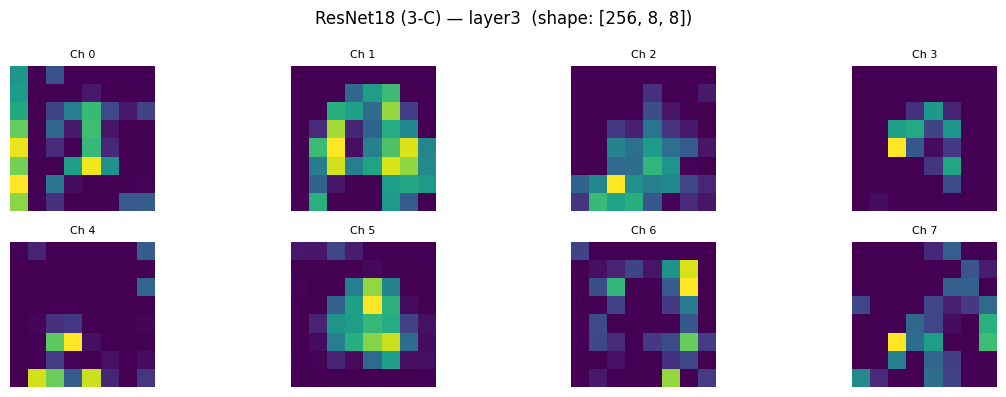

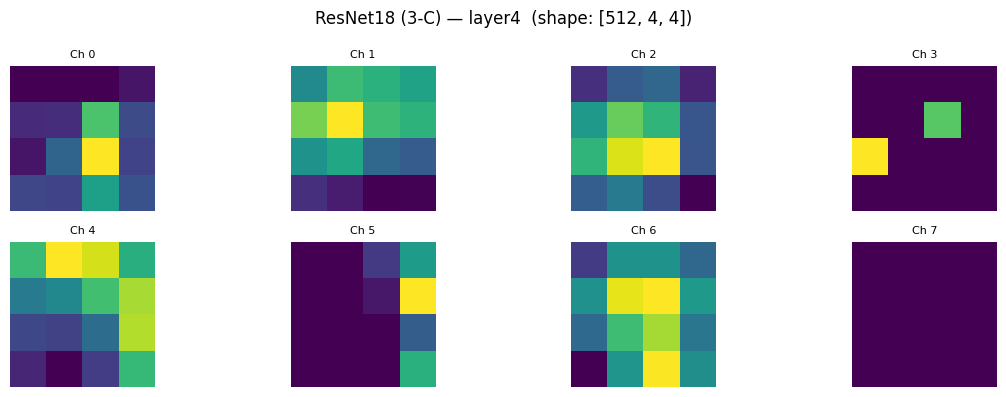


📋 Feature Map Observations:
  • Early layers (conv1, features.0): Respond to edges, color gradients, simple textures.
  • Middle layers (layer1-2, features.3): Combine edges into shapes and local patterns.
  • Deep layers (layer3-4): Capture high-level, class-specific patterns — disease spots, rust patches.
  • Spatial resolution shrinks deeper in the network while channel count grows.
  • Many channels become sparse/inactive deeper in the network — the model focuses on relevant features.


In [17]:
def get_feature_maps(model, image_tensor, target_layers):
    """Extract feature maps from specified layers using forward hooks."""
    feature_maps = {}
    hooks = []

    def make_hook(name):
        def hook_fn(module, input, output):
            feature_maps[name] = output.detach().cpu()
        return hook_fn

    # Register hooks on target layers
    for name, module in model.named_modules():
        if name in target_layers:
            hooks.append(module.register_forward_hook(make_hook(name)))

    # Forward pass
    model.eval()
    with torch.no_grad():
        model(image_tensor.to(device))

    # Remove hooks
    for h in hooks:
        h.remove()

    return feature_maps


def plot_feature_maps(feature_maps, num_maps=8, title_prefix=''):
    """Plot feature maps for each captured layer."""
    for layer_name, fmap in feature_maps.items():
        fmap = fmap.squeeze(0)  # Remove batch dim -> [C, H, W]
        n = min(num_maps, fmap.shape[0])
        fig, axes = plt.subplots(2, n // 2, figsize=(n * 1.5, 4))
        axes = axes.flatten()
        for i in range(n):
            ax = axes[i]
            ax.imshow(fmap[i].numpy(), cmap='viridis')
            ax.set_title(f'Ch {i}', fontsize=8)
            ax.axis('off')
        plt.suptitle(f'{title_prefix} \u2014 {layer_name}  (shape: {list(fmap.shape)})', fontsize=12)
        plt.tight_layout()
        plt.show()


# --- Prepare a sample image ---
sample_img, sample_label = val_dataset[0]
sample_input = sample_img.unsqueeze(0)  # Add batch dim

# Show the original image (un-normalized for display)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
display_img = inv_normalize(sample_img).clamp(0, 1).permute(1, 2, 0).numpy()
plt.figure(figsize=(3, 3))
plt.imshow(display_img)
plt.title(f'Input Image \u2014 class: {CLASS_NAMES[sample_label]}')
plt.axis('off')
plt.show()


# --- Feature maps from SimpleCNN ---
print('\n' + '='*60)
print('  Feature Maps: Simple CNN')
print('='*60)
cnn_layers = ['features.0', 'features.3']  # Conv layers in SimpleCNN
cnn_fmaps = get_feature_maps(simple_cnn, sample_input, cnn_layers)
plot_feature_maps(cnn_fmaps, num_maps=8, title_prefix='Simple CNN')


# --- Feature maps from Finetuned ResNet18 (model_c) ---
print('\n' + '='*60)
print('  Feature Maps: Finetuned ResNet18 (3-C)')
print('='*60)
resnet_layers = ['conv1', 'layer1', 'layer2', 'layer3', 'layer4']
resnet_fmaps = get_feature_maps(model_c, sample_input, resnet_layers)
plot_feature_maps(resnet_fmaps, num_maps=8, title_prefix='ResNet18 (3-C)')


print('\n\U0001f4cb Feature Map Observations:')
print('  \u2022 Early layers (conv1, features.0): Respond to edges, color gradients, simple textures.')
print('  \u2022 Middle layers (layer1-2, features.3): Combine edges into shapes and local patterns.')
print('  \u2022 Deep layers (layer3-4): Capture high-level, class-specific patterns \u2014 disease spots, rust patches.')
print('  \u2022 Spatial resolution shrinks deeper in the network while channel count grows.')
print('  \u2022 Many channels become sparse/inactive deeper in the network \u2014 the model focuses on relevant features.')

**Comment — Feature Map Visualization:**
- **Early layers** produce many active feature maps that look like edge-detected versions of the input — responding to horizontal, vertical, and diagonal edges as well as color contrasts.
- **Deeper layers** produce increasingly abstract and sparse activations. Only a few channels 'fire' strongly, indicating the model has learned to attend to disease-specific regions.
- **ResNet vs SimpleCNN**: The ResNet feature maps are richer and more structured at every depth thanks to skip connections and deeper architecture, which is reflected in its superior classification accuracy.
- **Spatial shrinkage**: Feature map resolution decreases with depth (128→64→32→16→...→4), while the channel count grows, compressing spatial information into a rich feature vector for classification.

---
# Summary & Comparison


          MODEL COMPARISON — Best Val Accuracy
  MLP                    :  73.68%  ████████████████████████████████████
  Simple CNN             :  82.71%  █████████████████████████████████████████
  Complex CNN            :  91.73%  █████████████████████████████████████████████
  Simple CNN + Reg       :  79.70%  ███████████████████████████████████████
  TL 3-A (FC only)       :  82.71%  █████████████████████████████████████████
  TL 3-B (layer4+FC)     :  91.73%  █████████████████████████████████████████████
  TL 3-C (Full)          :  96.24%  ████████████████████████████████████████████████


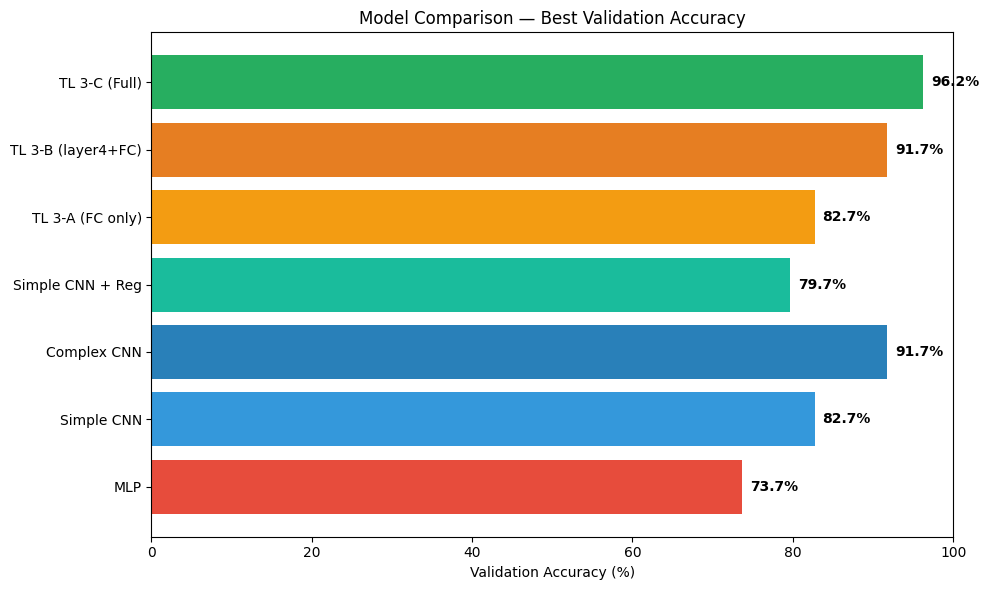


📋 Key Observations:
  1. MLP performs worst — it cannot leverage spatial structure in images.
  2. CNNs significantly outperform MLP by using convolutions for local feature extraction.
  3. Regularization helps the simple CNN generalize better (smaller train-val gap).
  4. Transfer Learning dominates — pretrained ImageNet features transfer well to bean leaves.
  5. Full finetuning (3-C) typically achieves the best accuracy by adapting all layers.
  6. Fine-tuning final layers (3-B) is a good balance between speed and performance.


In [18]:
# Collect all results
results = {
    'MLP':                   mlp_best_acc * 100,
    'Simple CNN':            simple_best * 100,
    'Complex CNN':           complex_best * 100,
    'Simple CNN + Reg':      reg_best * 100,
    'TL 3-A (FC only)':     best_a * 100,
    'TL 3-B (layer4+FC)':   best_b * 100,
    'TL 3-C (Full)':        best_c * 100,
}

print("\n" + "="*55)
print("          MODEL COMPARISON — Best Val Accuracy")
print("="*55)
for name, acc in results.items():
    bar = '█' * int(acc / 2)
    print(f"  {name:<22} : {acc:6.2f}%  {bar}")
print("="*55)

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
accs = list(results.values())
colors = ['#e74c3c', '#3498db', '#2980b9', '#1abc9c', '#f39c12', '#e67e22', '#27ae60']
bars = ax.barh(names, accs, color=colors)
ax.set_xlabel('Validation Accuracy (%)')
ax.set_title('Model Comparison — Best Validation Accuracy')
ax.set_xlim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📋 Key Observations:")
print("  1. MLP performs worst — it cannot leverage spatial structure in images.")
print("  2. CNNs significantly outperform MLP by using convolutions for local feature extraction.")
print("  3. Regularization helps the simple CNN generalize better (smaller train-val gap).")
print("  4. Transfer Learning dominates — pretrained ImageNet features transfer well to bean leaves.")
print("  5. Full finetuning (3-C) typically achieves the best accuracy by adapting all layers.")
print("  6. Fine-tuning final layers (3-B) is a good balance between speed and performance.")